# Interface metrics (L1KD)
* ipLDDT
* avg # interface residues
* SD # interface residues (across 5 models)

## 1. L1KD correlated proteins (class positive, 55)


### a) Metrics per model

In [9]:
import os
import pandas as pd
from Bio.PDB import PDBParser
from find_interface import find_interaction_surface

def calculate_mean_interface_plddt_new(pdb_file, residue_indexes):
    """Calculate the mean pLDDT for interface residues.

    Args:
        pdb_file (str): Path to the PDB file.
        residue_indexes (list): List of residue indexes.

    Returns:
        float: Mean pLDDT value for the interface residues.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    b_factors = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[1] in residue_indexes:  # Check if residue index matches
                    for atom in residue:
                        b_factors.append(atom.bfactor)

    if not b_factors:
        return None  # Return None instead of raising an error

    return sum(b_factors) / len(b_factors)

# Main processing script
folder_path = '/mnt/storage/ana01/results/all_models_FCpos_no_CLK2_original'
rows_final = {}

cutoff_distances = [4, 5, 6, 7, 8]  # Biologically relevant cutoff distances

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    if folder.endswith("multimer"):  #Ana's only change to Edie's version
        folder_full_path = os.path.join(folder_path, folder)
        
        for file_name in os.listdir(folder_full_path):
            if file_name.startswith('unrelaxed_') and file_name.endswith('.pdb'):
                result_file = os.path.join(folder_full_path, file_name)
                
                # Extract model name from the filename
                base_model_name = file_name.replace('unrelaxed_', '').replace('.pdb', '')

                if os.path.exists(result_file):
                    try:
                        # Store results in a dictionary
                        key = (folder, base_model_name)
                        if key not in rows_final:
                            rows_final[key] = {
                                'Target': folder,
                                'Model': base_model_name,  # Keep original format
                            }

                        # Loop through different cutoff distances
                        for cutoff in cutoff_distances:
                            # Find interface residues for the current cutoff
                            interaction_data = find_interaction_surface(result_file, cutoff)

                            # Get all interface residues across all chains
                            interface_residue_indexes = set()
                            for residues in interaction_data.values():
                                interface_residue_indexes.update(map(int, residues.keys()))

                            # Calculate interface pLDDT
                            if interface_residue_indexes:
                                mean_interface_plddt = calculate_mean_interface_plddt_new(result_file, list(interface_residue_indexes))
                                residues_in_interface = len(interface_residue_indexes)
                            else:
                                mean_interface_plddt = None
                                residues_in_interface = 0

                            # Store the values under a unique column name for each cutoff
                            rows_final[key][f'ipLDDT (cutoff {cutoff} Å)'] = mean_interface_plddt
                            rows_final[key][f'# Residues in Interface (cutoff {cutoff} Å)'] = residues_in_interface

                    except Exception as e:
                        print(f"Error processing {result_file}: {e}")

# Convert dictionary to DataFrame
df = pd.DataFrame(list(rows_final.values()))

In [10]:
df.head(10)

,Target,Model,ipLDDT (cutoff 4 Å),# Residues in Interface (cutoff 4 Å),ipLDDT (cutoff 5 Å),# Residues in Interface (cutoff 5 Å),ipLDDT (cutoff 6 Å),# Residues in Interface (cutoff 6 Å),ipLDDT (cutoff 7 Å),# Residues in Interface (cutoff 7 Å),ipLDDT (cutoff 8 Å),# Residues in Interface (cutoff 8 Å)
0,MRPS34_ORF2_multimer,model_1_multimer_v3_pred_0,67.387704,21,68.063594,37,70.261761,55,71.170831,66,71.995795,92
1,MRPS34_ORF2_multimer,model_4_multimer_v3_pred_0,66.732287,87,67.172787,106,67.577250,131,67.567816,156,67.836051,175
2,MRPS34_ORF2_multimer,model_5_multimer_v3_pred_0,66.916235,38,67.609515,43,67.923089,62,68.351950,82,68.561169,109
3,MRPS34_ORF2_multimer,model_2_multimer_v3_pred_0,70.479200,64,70.922188,77,70.911098,95,71.353615,110,71.627331,126
4,MRPS34_ORF2_multimer,model_3_multimer_v3_pred_0,68.304623,110,68.352904,134,68.017152,158,68.331346,176,68.656938,193
5,MAT2B_ORF2_multimer,model_1_multimer_v3_pred_0,72.172175,80,72.849482,95,74.230069,113,75.040079,140,75.830530,161
6,MAT2B_ORF2_multimer,model_4_multimer_v3_pred_0,67.348625,89,68.036171,97,69.517194,119,70.005960,134,70.886160,150
7,MAT2B_ORF2_multimer,model_5_multimer_v3_pred_0,68.269514,96,69.331596,123,70.190251,146,71.165697,170,71.782037,189
8,MAT2B_ORF2_multimer,model_2_multimer_v3_pred_0,73.173106,55,73.788790,78,74.725828,99,75.419874,122,76.279799,135
9,MAT2B_ORF2_multimer,model_3_multimer_v3_pred_0,73.874233,86,74.053414,107,74.410803,132,75.119264,164,75.988377,192


### b) Average ipLDDTs over 5 model predictions, at different cutoffs.

In [12]:
#Average ipLDDTs over 5 model predictions for each complex, at different cutoffs.

df_ipLDDT = df[['Target'] + [col for col in df.columns if col.startswith('ipLDDT')]]

df_ipLDDT_avg = (
    df_ipLDDT
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

df_ipLDDT_avg.head(10)

,Target,ipLDDT (cutoff 4 Å),ipLDDT (cutoff 5 Å),ipLDDT (cutoff 6 Å),ipLDDT (cutoff 7 Å),ipLDDT (cutoff 8 Å)
0,ACIN1_ORF2_multimer,51.254061,51.891364,52.509819,53.199085,53.605327
1,ALYREF_ORF2_multimer,65.041579,65.517054,66.417504,66.920810,67.456594
2,ARGLU1_ORF2_multimer,62.970513,62.677434,62.785431,62.860800,62.508642
3,ARL6IP4_ORF2_multimer,63.987460,64.345701,64.848242,65.118419,65.524112
4,ARRB1_ORF2_multimer,70.972207,71.189988,71.558969,71.929967,72.729321
5,ATXN2L_ORF2_multimer,53.068557,53.910447,53.977343,54.400948,54.704709
6,BCLAF1_ORF2_multimer,54.878298,55.408526,55.540473,55.950346,55.984112
7,CIR1_ORF2_multimer,59.624869,60.031273,60.257979,60.774021,61.106406
8,CLK1_ORF2_multimer,71.268346,71.415180,72.538294,73.476341,74.448863
9,CWC22_ORF2_multimer,70.338790,71.377971,72.311575,72.469873,72.850762


### c) Average # interacting residues over 5 model predictions, at different cutoffs.

In [13]:
#Average the number of residues in the interface.

df_residues = df[['Target'] + [col for col in df.columns if col.startswith('#')]]

df_residues_avg = (
    df_residues
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

df_residues_avg.head(10)

,Target,# Residues in Interface (cutoff 4 Å),# Residues in Interface (cutoff 5 Å),# Residues in Interface (cutoff 6 Å),# Residues in Interface (cutoff 7 Å),# Residues in Interface (cutoff 8 Å)
0,ACIN1_ORF2_multimer,136.8,186.2,240.4,301.0,358.6
1,ALYREF_ORF2_multimer,93.8,123.0,161.2,201.2,241.6
2,ARGLU1_ORF2_multimer,54.8,76.4,97.2,121.0,144.2
3,ARL6IP4_ORF2_multimer,95.8,132.0,170.2,208.8,249.6
4,ARRB1_ORF2_multimer,53.0,72.0,96.2,119.0,144.8
5,ATXN2L_ORF2_multimer,149.0,192.2,241.8,297.4,350.2
6,BCLAF1_ORF2_multimer,130.0,180.2,232.0,278.8,332.8
7,CIR1_ORF2_multimer,62.8,93.8,128.0,169.0,213.6
8,CLK1_ORF2_multimer,142.8,184.6,239.6,297.8,358.4
9,CWC22_ORF2_multimer,111.2,144.4,181.0,220.6,264.6


### d) SD interacting residues over 5 model predictions, at different cutoffs.

In [14]:
#SD of number of resifues in the interface across 5 model predictions per cutoff

df_residues_sd = (
    df_residues
    .groupby('Target')
    .std(numeric_only=True)
    .reset_index()
    .rename(columns=lambda col: f"SD {col}" if col != "Target" else col)
)

# Normalize SD by mean (relative variability)
df_residues_sd_norm = df_residues_sd.copy()

for col in df_residues_sd.columns:
    if col != "Target":
        # match SD column to corresponding mean column
        mean_col = col.replace("SD ", "")
        df_residues_sd_norm[col] = df_residues_sd[col] / df_residues_avg[mean_col]

df_residues_sd_norm.head(10)

,Target,SD # Residues in Interface (cutoff 4 Å),SD # Residues in Interface (cutoff 5 Å),SD # Residues in Interface (cutoff 6 Å),SD # Residues in Interface (cutoff 7 Å),SD # Residues in Interface (cutoff 8 Å)
0,ACIN1_ORF2_multimer,0.476056,0.507958,0.494944,0.474641,0.470057
1,ALYREF_ORF2_multimer,0.289755,0.266377,0.265208,0.282742,0.247266
2,ARGLU1_ORF2_multimer,0.169914,0.164942,0.171752,0.204368,0.235600
3,ARL6IP4_ORF2_multimer,0.298035,0.330654,0.316004,0.294947,0.270018
4,ARRB1_ORF2_multimer,0.331936,0.234677,0.265368,0.257574,0.273310
5,ATXN2L_ORF2_multimer,0.442470,0.420430,0.396348,0.384490,0.372282
6,BCLAF1_ORF2_multimer,0.276335,0.255435,0.223848,0.216911,0.210941
7,CIR1_ORF2_multimer,0.554405,0.559595,0.522767,0.492299,0.463868
8,CLK1_ORF2_multimer,0.366542,0.311557,0.273310,0.241323,0.210123
9,CWC22_ORF2_multimer,0.548023,0.498726,0.450353,0.400847,0.391887


### e) Export all three DataFrames to /mnt/storage/ana01/results/Interface_metrics_L1KD

In [15]:
#Export all three DataFrames to /mnt/storage/ana01/results/Interface_metrics_RNase
df_ipLDDT_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_L1KD/ipLDDT_avg_pos.csv', index=False)
df_residues_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_avg_pos.csv', index=False)
df_residues_sd_norm.to_csv('/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_sd_norm_pos.csv', index=False)

## 2. L1KD anti-correlated proteins (class negative, 89)

### a)

In [16]:
import os
import pandas as pd
from Bio.PDB import PDBParser
from find_interface import find_interaction_surface

def calculate_mean_interface_plddt_new(pdb_file, residue_indexes):
    """Calculate the mean pLDDT for interface residues.

    Args:
        pdb_file (str): Path to the PDB file.
        residue_indexes (list): List of residue indexes.

    Returns:
        float: Mean pLDDT value for the interface residues.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    b_factors = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[1] in residue_indexes:  # Check if residue index matches
                    for atom in residue:
                        b_factors.append(atom.bfactor)

    if not b_factors:
        return None  # Return None instead of raising an error

    return sum(b_factors) / len(b_factors)

# Main processing script
folder_path = '/mnt/storage/ana01/results/afm_6_L1KD_FCneg_no__MACF1_ABCG2_original'
rows_final = {}

cutoff_distances = [2, 3, 4, 5, 6, 7, 8]  # Different cutoff distances; custom = adding 2 and 3

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    if folder.endswith("multimer"):   #Ana's only change to Edie's version
        folder_full_path = os.path.join(folder_path, folder)
        
        for file_name in os.listdir(folder_full_path):
            if file_name.startswith('unrelaxed_') and file_name.endswith('.pdb'):
                result_file = os.path.join(folder_full_path, file_name)
                
                # Extract model name from the filename
                base_model_name = file_name.replace('unrelaxed_', '').replace('.pdb', '')

                if os.path.exists(result_file):
                    try:
                        # Store results in a dictionary
                        key = (folder, base_model_name)
                        if key not in rows_final:
                            rows_final[key] = {
                                'Target': folder,
                                'Model': base_model_name,  # Keep original format
                            }

                        # Loop through different cutoff distances
                        for cutoff in cutoff_distances:
                            # Find interface residues for the current cutoff
                            interaction_data = find_interaction_surface(result_file, cutoff)

                            # Get all interface residues across all chains
                            interface_residue_indexes = set()
                            for residues in interaction_data.values():
                                interface_residue_indexes.update(map(int, residues.keys()))

                            # Calculate interface pLDDT
                            if interface_residue_indexes:
                                mean_interface_plddt = calculate_mean_interface_plddt_new(result_file, list(interface_residue_indexes))
                                residues_in_interface = len(interface_residue_indexes)
                            else:
                                mean_interface_plddt = None
                                residues_in_interface = 0

                            # Store the values under a unique column name for each cutoff
                            rows_final[key][f'ipLDDT (cutoff {cutoff} Å)'] = mean_interface_plddt
                            rows_final[key][f'# Residues in Interface (cutoff {cutoff} Å)'] = residues_in_interface

                    except Exception as e:
                        print(f"Error processing {result_file}: {e}")

# Convert dictionary to DataFrame
df = pd.DataFrame(list(rows_final.values()))

In [17]:
df.head(10)

,Target,Model,ipLDDT (cutoff 2 Å),# Residues in Interface (cutoff 2 Å),ipLDDT (cutoff 3 Å),# Residues in Interface (cutoff 3 Å),ipLDDT (cutoff 4 Å),# Residues in Interface (cutoff 4 Å),ipLDDT (cutoff 5 Å),# Residues in Interface (cutoff 5 Å),ipLDDT (cutoff 6 Å),# Residues in Interface (cutoff 6 Å),ipLDDT (cutoff 7 Å),# Residues in Interface (cutoff 7 Å),ipLDDT (cutoff 8 Å),# Residues in Interface (cutoff 8 Å)
0,SCFD1_ORF2_multimer,model_1_multimer_v3_pred_0,71.951557,47,73.106939,63,74.249927,82,72.874638,101,73.182660,121,73.588340,149,73.888872,172
1,SCFD1_ORF2_multimer,model_4_multimer_v3_pred_0,68.961291,40,71.053918,71,71.051404,98,71.185016,115,72.147914,138,73.359305,163,74.135197,185
2,SCFD1_ORF2_multimer,model_5_multimer_v3_pred_0,70.179039,41,71.667952,66,72.902289,91,73.121325,109,74.191668,129,74.328966,152,74.698843,174
3,SCFD1_ORF2_multimer,model_2_multimer_v3_pred_0,75.472894,22,75.027103,42,74.844786,71,74.902452,99,75.040651,127,74.823813,154,75.158254,182
4,SCFD1_ORF2_multimer,model_3_multimer_v3_pred_0,74.582139,37,74.800490,64,74.847349,95,74.973554,127,76.064116,151,76.258950,180,76.309799,217
5,ACAD11_ORF2_multimer,model_1_multimer_v3_pred_0,69.501209,29,71.002732,56,73.863465,91,75.125686,114,75.038152,149,76.371249,178,77.262506,211
6,ACAD11_ORF2_multimer,model_4_multimer_v3_pred_0,64.143167,13,66.416163,28,67.324149,37,68.490034,58,69.957792,83,71.642831,112,71.709260,131
7,ACAD11_ORF2_multimer,model_5_multimer_v3_pred_0,73.419108,26,74.131736,35,72.884407,52,74.259593,75,73.930487,100,73.979585,113,75.066204,139
8,ACAD11_ORF2_multimer,model_2_multimer_v3_pred_0,73.567646,55,74.366444,77,74.035174,94,75.254328,117,76.229118,139,76.567222,163,76.969557,183
9,ACAD11_ORF2_multimer,model_3_multimer_v3_pred_0,61.878357,17,66.945879,32,70.109314,57,70.437433,81,70.923303,94,72.155322,123,73.470193,146


In [18]:
df.shape

(435, 16)

### b) c) d) e)

In [19]:
#Average ipLDDTs over 5 model predictions for each complex, at different cutoffs.

df_ipLDDT = df[['Target'] + [col for col in df.columns if col.startswith('ipLDDT')]]

df_ipLDDT_avg = (
    df_ipLDDT
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

#Average the number of residues in the interface.

df_residues = df[['Target'] + [col for col in df.columns if col.startswith('#')]]

df_residues_avg = (
    df_residues
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

#SD of number of resifues in the interface across 5 model predictions per cutoff

df_residues_sd = (
    df_residues
    .groupby('Target')
    .std(numeric_only=True)
    .reset_index()
    .rename(columns=lambda col: f"SD {col}" if col != "Target" else col)
)

# Normalize SD by mean (relative variability)
df_residues_sd_norm = df_residues_sd.copy()

for col in df_residues_sd.columns:
    if col != "Target":
        # match SD column to corresponding mean column
        mean_col = col.replace("SD ", "")
        df_residues_sd_norm[col] = df_residues_sd[col] / df_residues_avg[mean_col]

#Export all three DataFrames to /mnt/storage/ana01/results/Interface_metrics_RNase
#Export all three DataFrames to /mnt/storage/ana01/results/Interface_metrics_L1KD
df_ipLDDT_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_L1KD/ipLDDT_avg_neg.csv', index=False)
df_residues_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_avg_neg.csv', index=False)
df_residues_sd_norm.to_csv('/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_sd_norm_neg.csv', index=False)


## 3. STATISTICAL TESTING (MWU) AND VISUALIZATION

### a) ipLDDT per cutoff

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_pos = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_L1KD/ipLDDT_avg_pos.csv")
df_neg = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_L1KD/ipLDDT_avg_neg.csv")

sns.set(style="darkgrid", context="paper")

In [21]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

results = []

iplddt_cols = [col for col in df_pos.columns if col.startswith("ipLDDT")]

for col in iplddt_cols:

    # Perform one-sided Mann–Whitney U test
    U, p = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"   # H1: pos > neg
    )

    results.append({
        "Cutoff": col,
        "U_statistic": U,
        "p_value": p
    })

# Convert to DataFrame
df_mwu_results = pd.DataFrame(results)

df_mwu_results["significance"] = pd.cut(
    df_mwu_results["p_value"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

# Correction for multiple testing using Benjamini–Hochberg FDR
reject, p_adj, _, _ = multipletests(
    df_mwu_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

df_mwu_results["p_adj"] = p_adj
df_mwu_results["reject_H0"] = reject

df_mwu_results["significance_adj"] = pd.cut(
    df_mwu_results["p_adj"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

df_mwu_results

,Cutoff,U_statistic,p_value,significance,p_adj,reject_H0,significance_adj
0,ipLDDT (cutoff 4 Å),1829.0,0.990909,ns,0.99234,False,ns
1,ipLDDT (cutoff 5 Å),1817.0,0.992071,ns,0.99234,False,ns
2,ipLDDT (cutoff 6 Å),1818.0,0.991979,ns,0.99234,False,ns
3,ipLDDT (cutoff 7 Å),1814.0,0.992340,ns,0.99234,False,ns
4,ipLDDT (cutoff 8 Å),1819.0,0.991887,ns,0.99234,False,ns


Histograms (Figures A8 and A9)

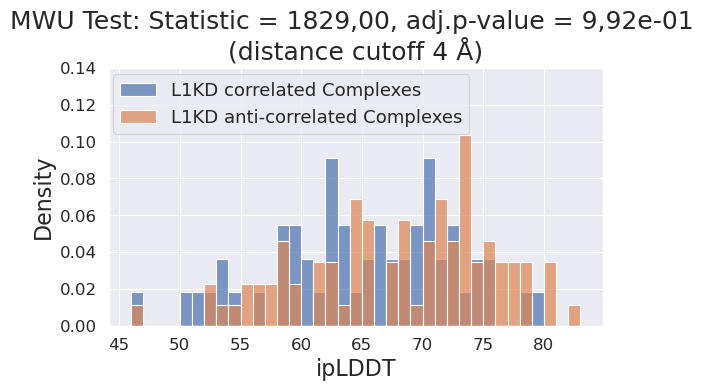

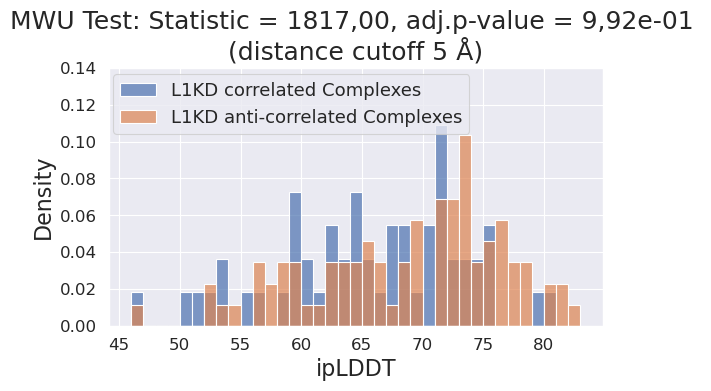

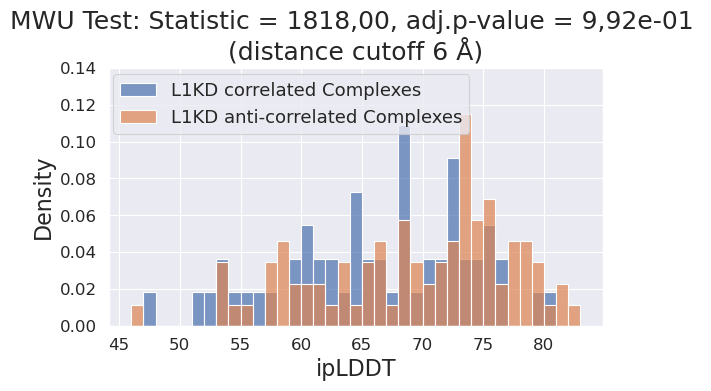

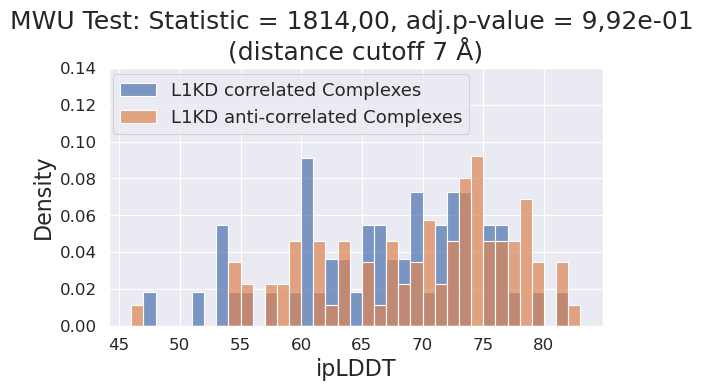

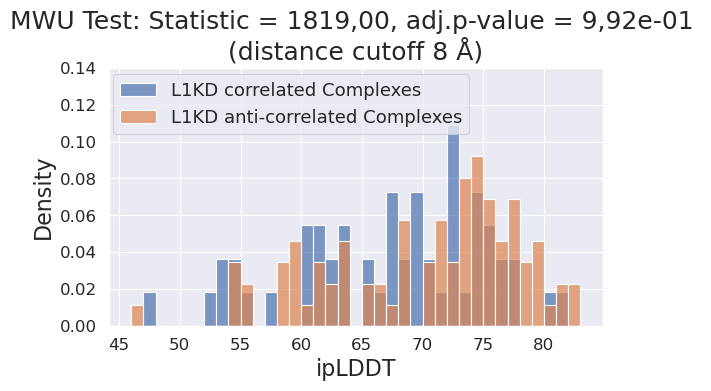

In [22]:
import numpy as np

for col in iplddt_cols:
    plt.figure(figsize=(6, 4))

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 1
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD correlated Complexes",
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD anti-correlated Complexes",
    )

    # MWU results for this column
    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    U_stat = row["U_statistic"]
    p_val = row["p_adj"]  # Use FDR-adjusted p-value

    cutoff_value = "".join(
        [c for c in str(col) if (c.isdigit() or c == ".")]
    )

    title = (
        f"MWU Test: Statistic = {U_stat:.2f}, adj.p-value = {p_val:.2e} \n"
        f"(distance cutoff {cutoff_value} Å)"
    )
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    plt.title(title, fontsize=18)

    plt.xlabel("ipLDDT", fontsize=16)
    plt.ylabel("Density", fontsize=16)

    ticks = np.arange(np.floor(min_edge)-1, np.ceil(max_edge) + 1, 5)
    labels = ["0" if abs(x) < 1e-9 else str(int(x)) for x in ticks]

    plt.xticks(ticks, labels, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 0.14)

    plt.legend(fontsize=13, loc="upper left", bbox_to_anchor=(-0.01, 1.01))

    plt.tight_layout()
    plt.savefig(
        f"/mnt/storage/ana01/results/figures/L1KD/hist_{col.replace(' ', '_').replace('Å','A')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

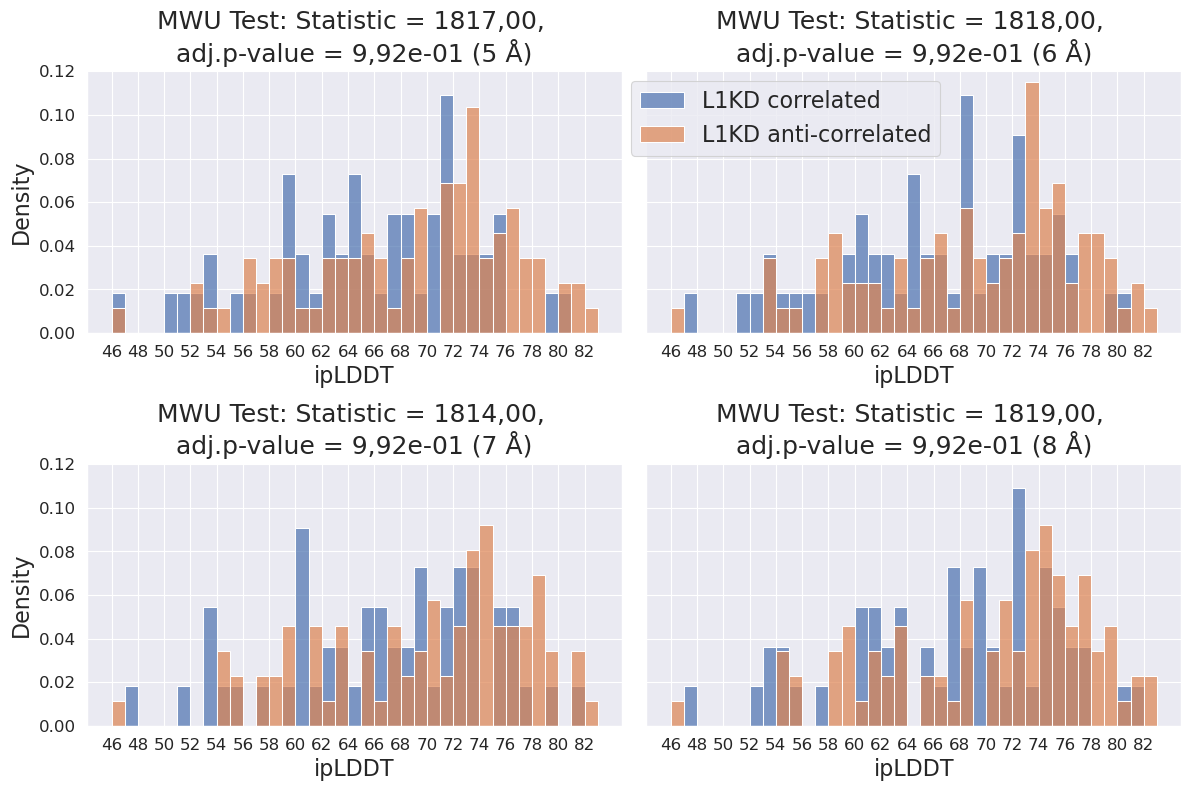

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iplddt_cols_subset = sorted(
    [col for col in iplddt_cols if any(k in col for k in ["5", "6", "7", "8"])],
    key=lambda x: float("".join(c for c in x if (c.isdigit() or c == ".")))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, iplddt_cols_subset):

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 1
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD correlated",
        ax=ax
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD anti-correlated",
        ax=ax
    )

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    U_stat = row["U_statistic"]
    p_val = row["p_adj"]  # FDR-adjusted p-value

    cutoff_value = "".join(
        [c for c in str(col) if (c.isdigit() or c == ".")]
    )

    title = (
        f"MWU Test: Statistic = {U_stat:.2f}, \n"
        f"adj.p-value = {p_val:.2e} ({cutoff_value} Å)"
    )
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("ipLDDT", fontsize=16)
    ax.set_ylabel("Density", fontsize=16)

    ticks = np.arange(np.floor(min_edge), np.ceil(max_edge) + 1, 2)
    labels = ["0" if abs(x) < 1e-9 else str(int(x)) for x in ticks]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.tick_params(axis="both", labelsize=12)

axes[1].legend(fontsize=16, loc="upper left", bbox_to_anchor=(-0.05, 1))

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/L1KD/ipLDDT_2x2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Adjusted p-value overview (Figure A8 B)

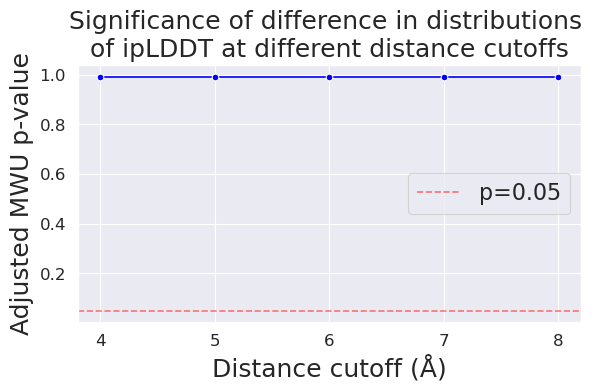

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid", context="paper")

df_plot = df_mwu_results.copy()
df_plot['Cutoff_Å'] = df_plot['Cutoff'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=df_plot,
    x='Cutoff_Å',
    y='p_adj',
    marker='o',
    color='blue'
)

plt.axhline(
    0.05,
    linestyle='--',
    color='red',
    alpha=0.5,
    label='p=0.05'
)

plt.xlabel("Distance cutoff (Å)", fontsize=18)
plt.ylabel("Adjusted MWU p-value", fontsize=18)
plt.title(
    "Significance of difference in distributions \n"
    "of ipLDDT at different distance cutoffs",
    fontsize=18
)

plt.xticks(df_plot['Cutoff_Å'], fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=16)

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/L1KD/ipLDDT_pvalues_vs_cutoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### b) Number of interface residues per cutoff

MWU one-sided

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_pos = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_avg_pos.csv")
df_neg = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_avg_neg.csv")

# Seaborn style
sns.set(style="darkgrid", context="paper")

In [26]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

num_res_cols = [col for col in df_pos.columns if col.startswith("#")]
results = []

for col in num_res_cols:

    # Perform one-sided Mann–Whitney U test
    U, p = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"   # H1: pos > neg
    )

    results.append({
        "Cutoff": col,
        "U_statistic": U,
        "p_value": p
    })

# Convert to DataFrame
df_mwu_results = pd.DataFrame(results)

# Raw p-value significance
df_mwu_results["significance"] = pd.cut(
    df_mwu_results["p_value"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

# Benjamini–Hochberg FDR correction
reject, p_adj, _, _ = multipletests(
    df_mwu_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

df_mwu_results["p_adj"] = p_adj
df_mwu_results["reject_H0"] = reject

# Adjusted p-value significance
df_mwu_results["significance_adj"] = pd.cut(
    df_mwu_results["p_adj"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

df_mwu_results

,Cutoff,U_statistic,p_value,significance,p_adj,reject_H0,significance_adj
0,# Residues in Interface (cutoff 4 Å),2990.5,0.006171,**,0.006171,True,**
1,# Residues in Interface (cutoff 5 Å),3017.5,0.004458,**,0.005572,True,**
2,# Residues in Interface (cutoff 6 Å),3035.5,0.003566,**,0.005572,True,**
3,# Residues in Interface (cutoff 7 Å),3051.5,0.002911,**,0.005572,True,**
4,# Residues in Interface (cutoff 8 Å),3055.5,0.002765,**,0.005572,True,**


Histograms (Figure 17 and A11)

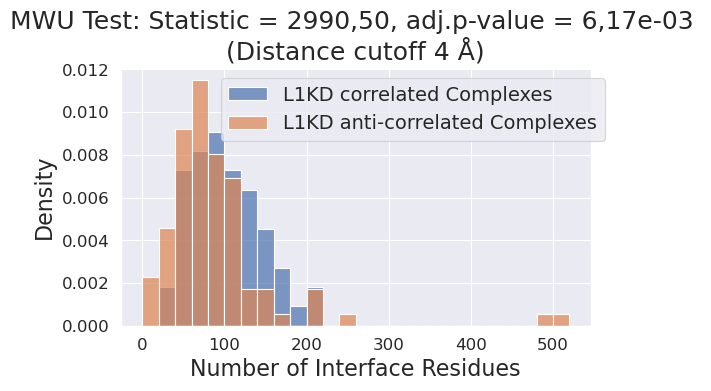

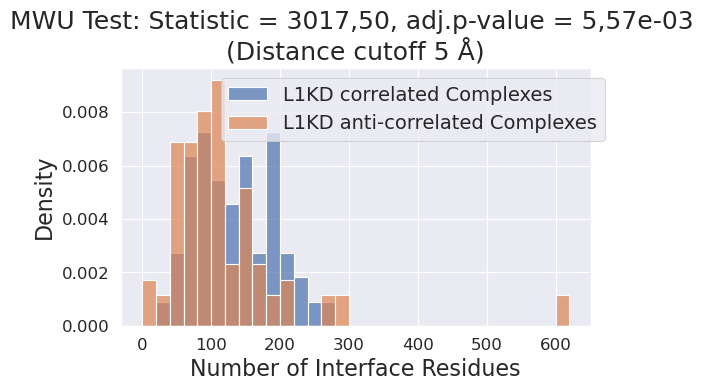

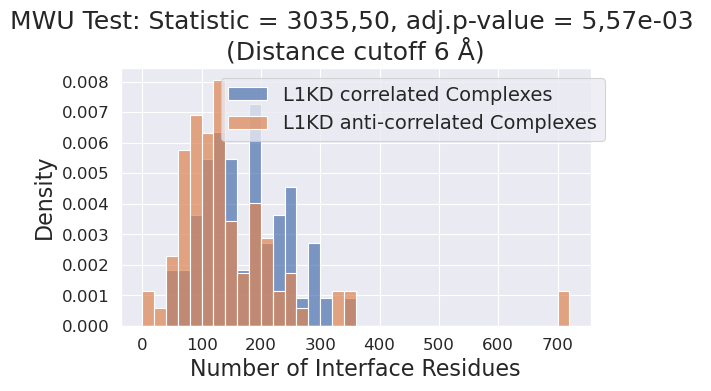

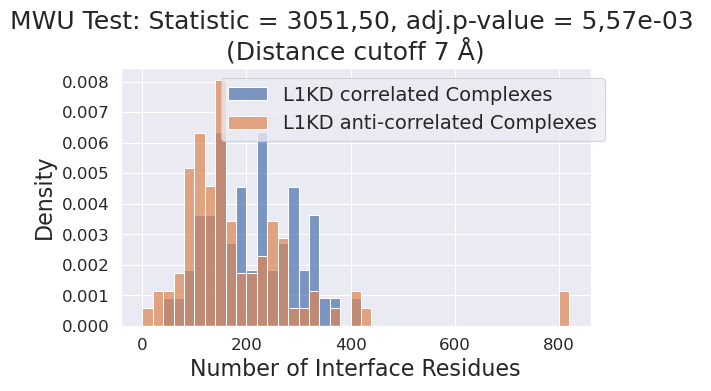

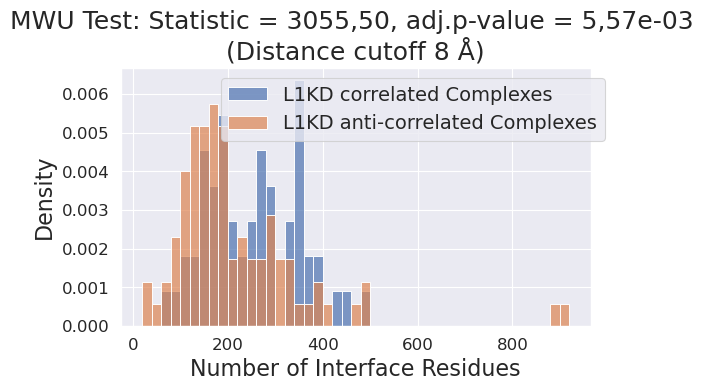

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

num_res_cols = [col for col in df_pos.columns if col.startswith("#")]

for col in num_res_cols:

    U_stat, p_value = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"
    )

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]

    combined = pd.concat([df_pos[col], df_neg[col]])
    bin_width = 20
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    cutoff_value = "".join(
        [c for c in str(col) if (c.isdigit() or c == ".")]
    )

    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD correlated Complexes",
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD anti-correlated Complexes",
    )

    title = (
        f"MWU Test: Statistic = {U_stat:.2f}, adj.p-value = {p_adj:.2e} \n"
        f"(Distance cutoff {cutoff_value} Å)"
    )
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    plt.title(title, fontsize=18)

    plt.xlabel("Number of Interface Residues", fontsize=16)
    plt.ylabel("Density", fontsize=16)

    plt.legend(fontsize=14, loc="upper right", bbox_to_anchor=(1.05, 1))

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()

    plt.savefig(
        f"/mnt/storage/ana01/results/figures/L1KD/hist_{col.replace(' ', '_').replace('Å','A')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

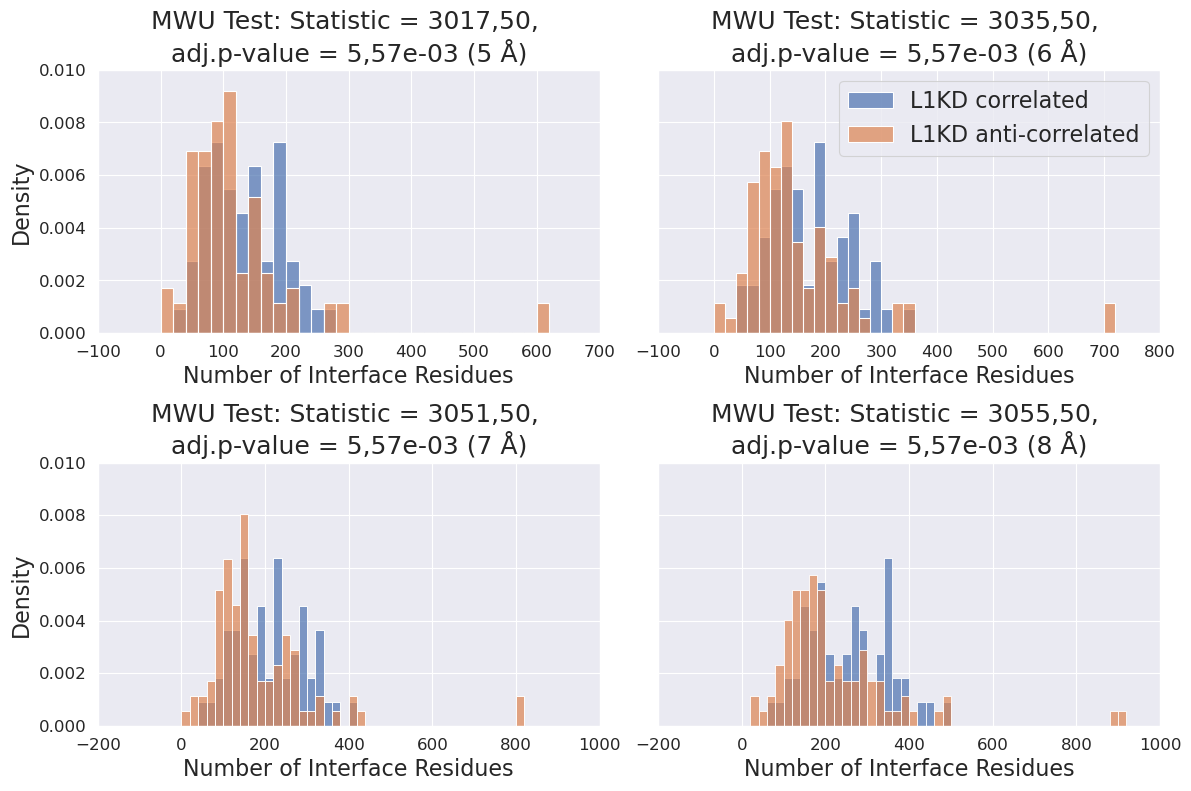

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

num_res_cols_subset = sorted(
    [col for col in num_res_cols if any(k in col for k in ["5", "6", "7", "8"])],
    key=lambda x: float("".join(c for c in x if (c.isdigit() or c == ".")))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, num_res_cols_subset):

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 20
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD correlated",
        ax=ax
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD anti-correlated",
        ax=ax
    )

    U_stat, _ = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"
    )

    cutoff_value = "".join(
        [c for c in str(col) if (c.isdigit() or c == ".")]
    )

    title = (
        f"MWU Test: Statistic = {U_stat:.2f}, \n"
        f"adj.p-value = {p_adj:.2e} ({cutoff_value} Å)"
    )
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    ax.set_title(title, fontsize=18)

    ax.set_xlabel("Number of Interface Residues", fontsize=16)
    ax.set_ylabel("Density", fontsize=16)

    ax.tick_params(axis="both", labelsize=12)

    ax.set_xticks(ax.get_xticks())
    ax.set_yticks(ax.get_yticks())

axes[1].legend(fontsize=16, loc="upper right")

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/L1KD/interface_residues_2x2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

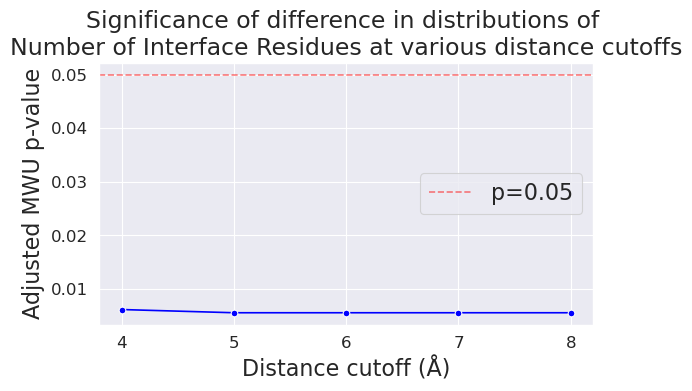

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn style
sns.set(style="darkgrid", context="paper")

# Make a copy for plotting
df_plot = df_mwu_results.copy()

# Convert cutoff labels to numbers for plotting
df_plot['Cutoff_Å'] = df_plot['Cutoff'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=df_plot,
    x='Cutoff_Å',
    y='p_adj',
    marker='o',
    color='blue'
)

# Horizontal line for significance threshold
plt.axhline(
    0.05,
    linestyle='--',
    color='red',
    alpha=0.5,
    label='p=0.05'
)

plt.xlabel("Distance cutoff (Å)", fontsize=16)
plt.ylabel("Adjusted MWU p-value", fontsize=16)

plt.title(
    "Significance of difference in distributions of \n"
    "Number of Interface Residues at various distance cutoffs",
    fontsize=17
)

plt.xticks(df_plot['Cutoff_Å'], fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=16)

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/L1KD/interface_residues_pvalues_vs_cutoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### c) SD in number of residues per cutoff

MWU one-sided

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_pos = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_sd_norm_pos.csv")
df_neg = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_L1KD/num_residues_sd_norm_neg.csv")
# Seaborn style
sns.set(style="darkgrid", context="paper")

In [34]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

sd_res_cols = [col for col in df_pos.columns if col.startswith("SD")]
results = []

for col in sd_res_cols:

    # Perform one-sided Mann–Whitney U test
    U, p = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"   # H1: pos > neg
    )

    results.append({
        "Cutoff": col,
        "U_statistic": U,
        "p_value": p
    })

# Convert to DataFrame
df_mwu_results = pd.DataFrame(results)

# Raw significance
df_mwu_results["significance"] = pd.cut(
    df_mwu_results["p_value"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

# Benjamini–Hochberg FDR correction
reject, p_adj, _, _ = multipletests(
    df_mwu_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

df_mwu_results["p_adj"] = p_adj
df_mwu_results["reject_H0"] = reject

# Adjusted significance
df_mwu_results["significance_adj"] = pd.cut(
    df_mwu_results["p_adj"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

df_mwu_results

,Cutoff,U_statistic,p_value,significance,p_adj,reject_H0,significance_adj
0,SD # Residues in Interface (cutoff 4 Å),2365.0,0.546672,ns,0.546672,False,ns
1,SD # Residues in Interface (cutoff 5 Å),2420.0,0.454988,ns,0.546672,False,ns
2,SD # Residues in Interface (cutoff 6 Å),2497.0,0.331590,ns,0.546672,False,ns
3,SD # Residues in Interface (cutoff 7 Å),2535.0,0.276035,ns,0.546672,False,ns
4,SD # Residues in Interface (cutoff 8 Å),2574.0,0.224230,ns,0.546672,False,ns


Plotting (Figures A12 and A13)

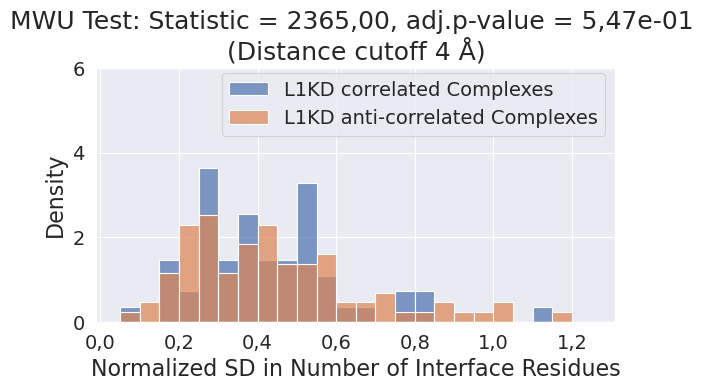

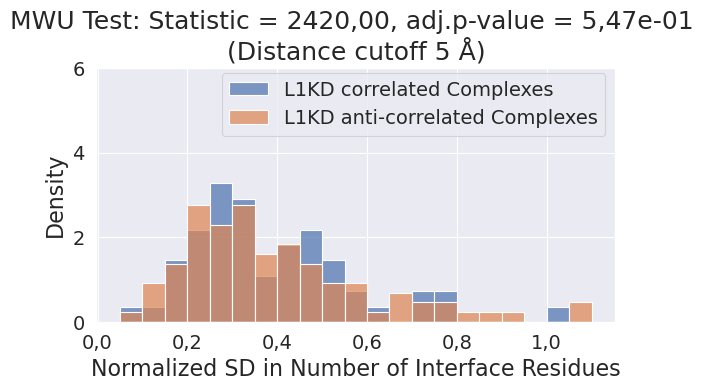

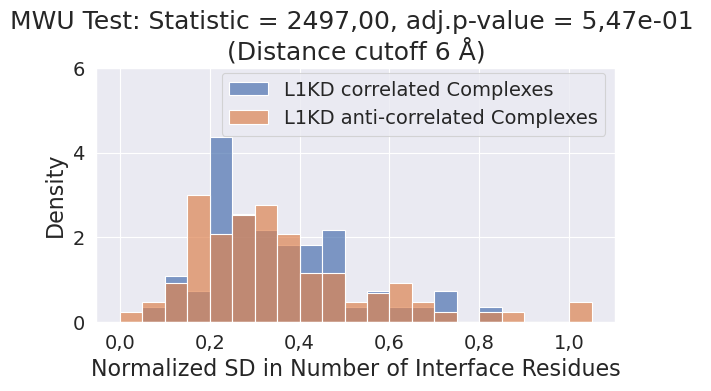

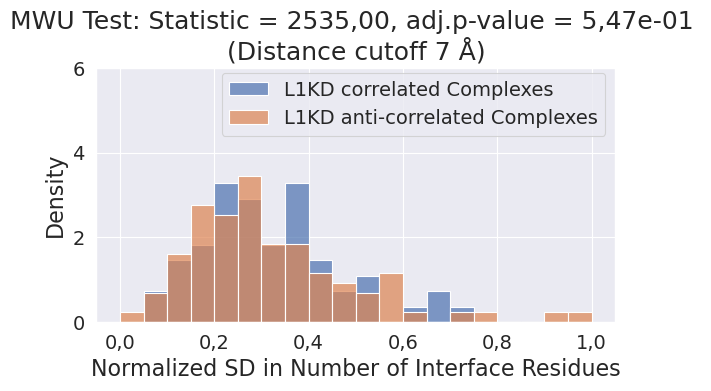

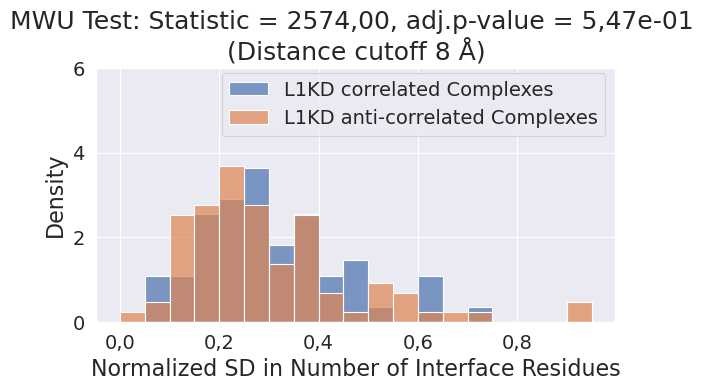

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MultipleLocator

sd_res_cols = [col for col in df_pos.columns if col.startswith("SD")]

for col in sd_res_cols:

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]
    U_stat = row["U_statistic"]

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 0.05
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    cutoff_value = "".join([c for c in str(col) if (c.isdigit() or c == ".")])

    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD correlated Complexes",
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD anti-correlated Complexes",
    )

    title = (
        f"MWU Test: Statistic = {U_stat:.2f}, adj.p-value = {p_adj:.2e} \n"
        f"(Distance cutoff {cutoff_value} Å)"
    )
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    plt.title(title, fontsize=18)

    plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
)

    plt.xlabel("Normalized SD in Number of Interface Residues", fontsize=16)
    plt.ylabel("Density", fontsize=16)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.gca().yaxis.set_major_locator(MultipleLocator(2))

    plt.legend(fontsize=14, loc="upper right", bbox_to_anchor=(1, 1.02))

    plt.ylim(0, 6)

    plt.tight_layout()

    plt.savefig(
        f"/mnt/storage/ana01/results/figures/L1KD/hist_{col.replace(' ', '_').replace('Å','A')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

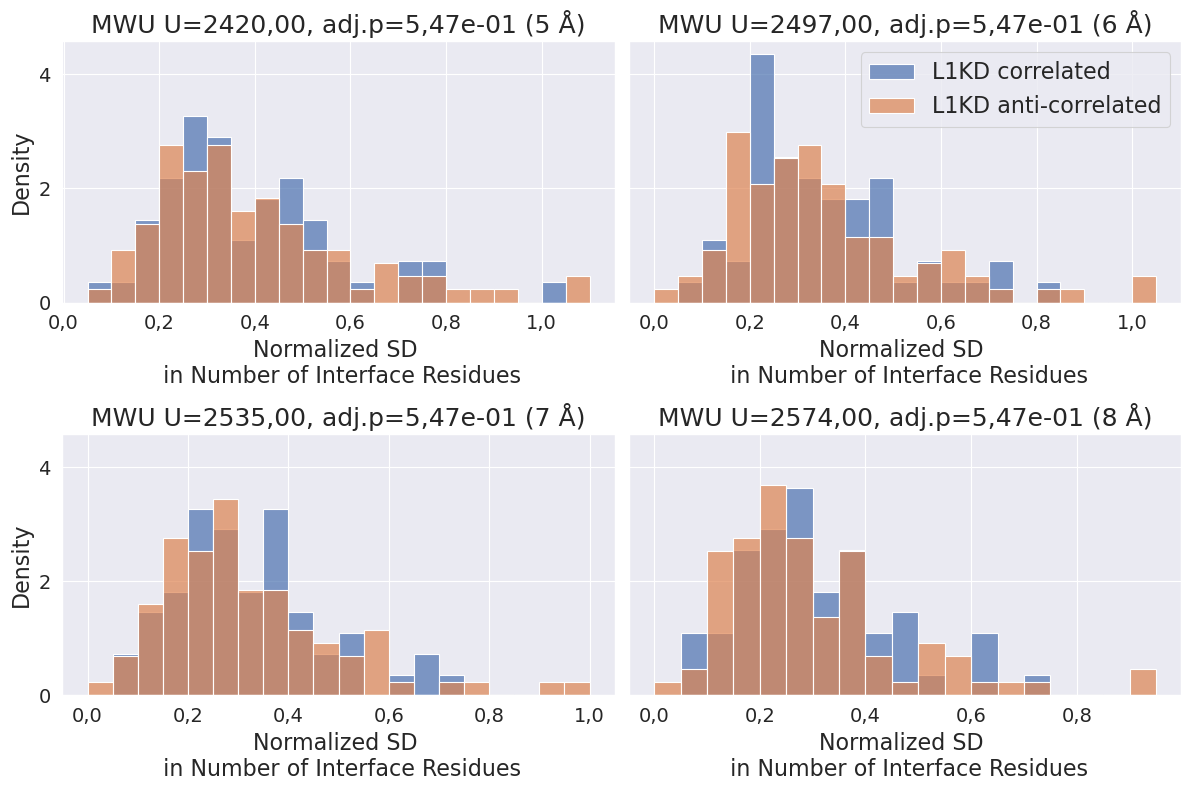

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

sd_res_cols_subset = sorted(
    [
        col for col in df_pos.columns
        if col.startswith("SD") and any(k in col for k in ["5", "6", "7", "8"])
    ],
    key=lambda x: float("".join(c for c in x if (c.isdigit() or c == ".")))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, sd_res_cols_subset):

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]
    U_stat = row["U_statistic"]

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 0.05
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    cutoff_value = "".join(
        [c for c in str(col) if (c.isdigit() or c == ".")]
    )

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD correlated",
        ax=ax
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="L1KD anti-correlated",
        ax=ax
    )

    title = f"MWU U={U_stat:.2f}, adj.p={p_adj:.2e} ({cutoff_value} Å)"
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    ax.set_title(title, fontsize=18)

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
    )

    ax.yaxis.set_major_locator(MultipleLocator(2))

    ax.tick_params(axis="both", labelsize=14)

    ax.set_xlabel(
        "Normalized SD \n in Number of Interface Residues",
        fontsize=16
    )

axes[0].set_ylabel("Density", fontsize=16)
axes[2].set_ylabel("Density", fontsize=16)

axes[1].legend(fontsize=16, loc="upper right")

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/L1KD/SD_hist_2x2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

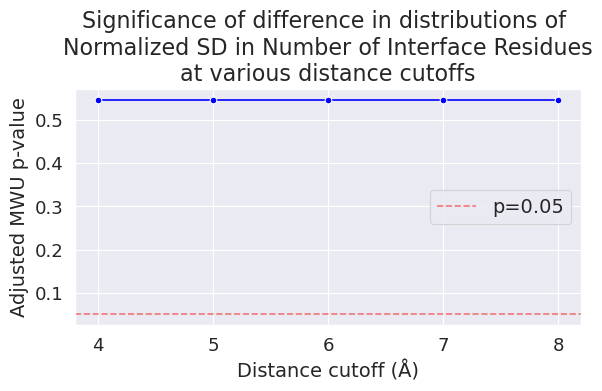

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid", context="paper")

df_plot = df_mwu_results.copy()
df_plot['Cutoff_Å'] = df_plot['Cutoff'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=df_plot,
    x='Cutoff_Å',
    y='p_adj',
    marker='o',
    color='blue'
)

plt.axhline(
    0.05,
    linestyle='--',
    color='red',
    alpha=0.5,
    label='p=0.05'
)

plt.xlabel("Distance cutoff (Å)", fontsize=14)
plt.ylabel("Adjusted MWU p-value", fontsize=14)

plt.title(
    "Significance of difference in distributions of \n"
    "Normalized SD in Number of Interface Residues\n"
    "at various distance cutoffs",
    fontsize=16
)

plt.xticks(df_plot['Cutoff_Å'], fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=14)

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/L1KD/SD_pvalues_vs_cutoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()